In [63]:
import chainladder as cl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%config InlineBackend.figure_format = 'retina'

from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

import shutil
import os
import sys
import subprocess

In [64]:
ruta = r"C:\Users\darkr\OneDrive\Documents\OneDrive\Documentos\ITAM\Riesgos\00_caso de estudio\nf_INCENDIO__202506.xlsx"

In [65]:
# Carga de triangulos

# 1) Leer Excel
df = pd.read_excel(
    ruta,
    sheet_name="base",
    header=0,      # fila 24 de Excel como encabezado
    usecols="A:D"
)

ocu_inc = cl.Triangle(df,origin='origen',development='reporte',columns='ocurrido',cumulative=False)
pag_inc = cl.Triangle(df,origin='origen',development='reporte',columns='pagado',cumulative=False)

#Triángulos acumulados
ocu_acum = ocu_inc.incr_to_cum()
pag_acum = pag_inc.incr_to_cum()

#prima dev
pr_dev = pd.read_excel(
    ruta,
    sheet_name="prima_dev",
    header=0,      # fila 24 de Excel como encabezado
    usecols="A:B"
)

ind_risk = pd.read_excel(
    ruta,
    sheet_name="indice",
    header=0,      # fila 24 de Excel como encabezado
    usecols="A:B"
)

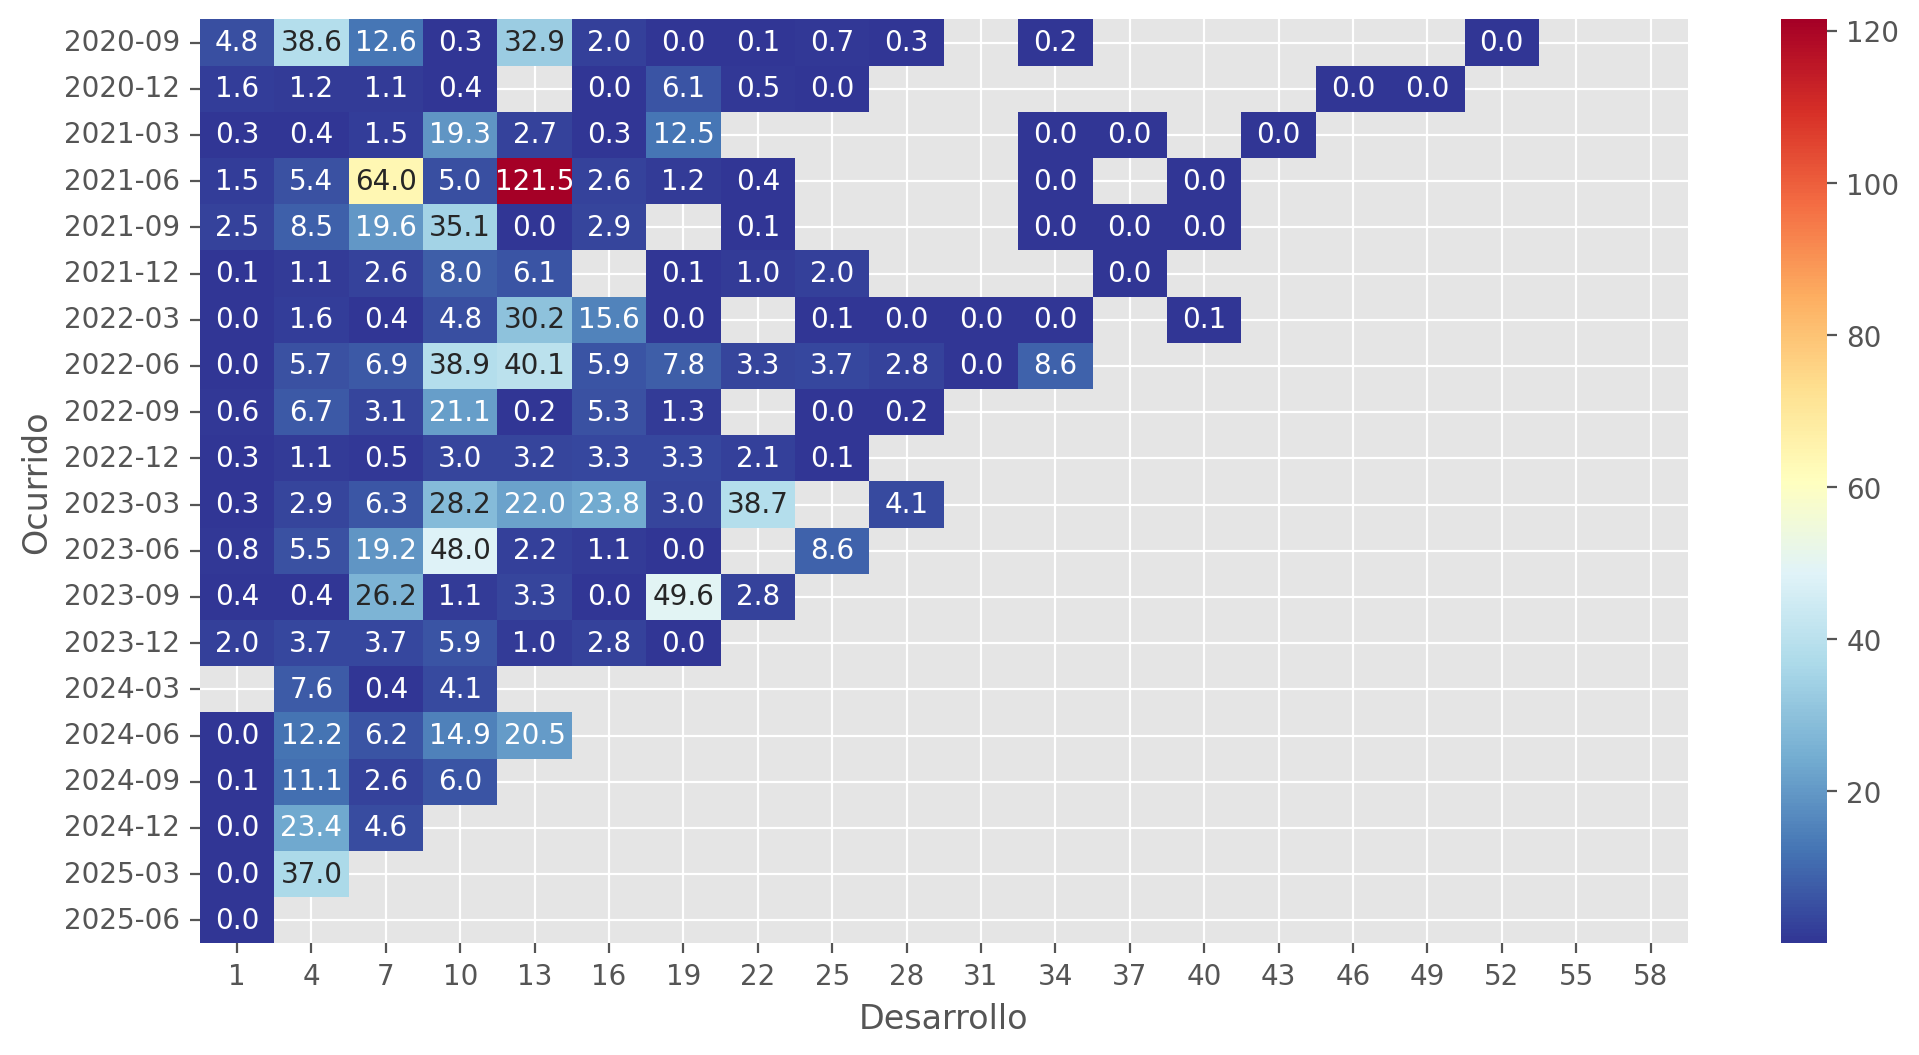

In [66]:
ax = pag_inc.heatmap()

df_lr = pag_inc
df_lr = (pag_inc/1000000).to_frame()  # o .values según la librería
df_lr.index = pd.to_datetime(df_lr.index).strftime('%Y-%m')
plt.figure(figsize=(12,6))

sns.heatmap(
    df_lr,
    cmap="RdYlBu_r",
    annot=True,   # cambia a True si quieres números
    fmt=".1f",
    cbar=True
)


plt.xlabel("Desarrollo")
plt.ylabel("Ocurrido")

plt.savefig("montos_pagado.png", dpi=300, bbox_inches="tight")
plt.show()

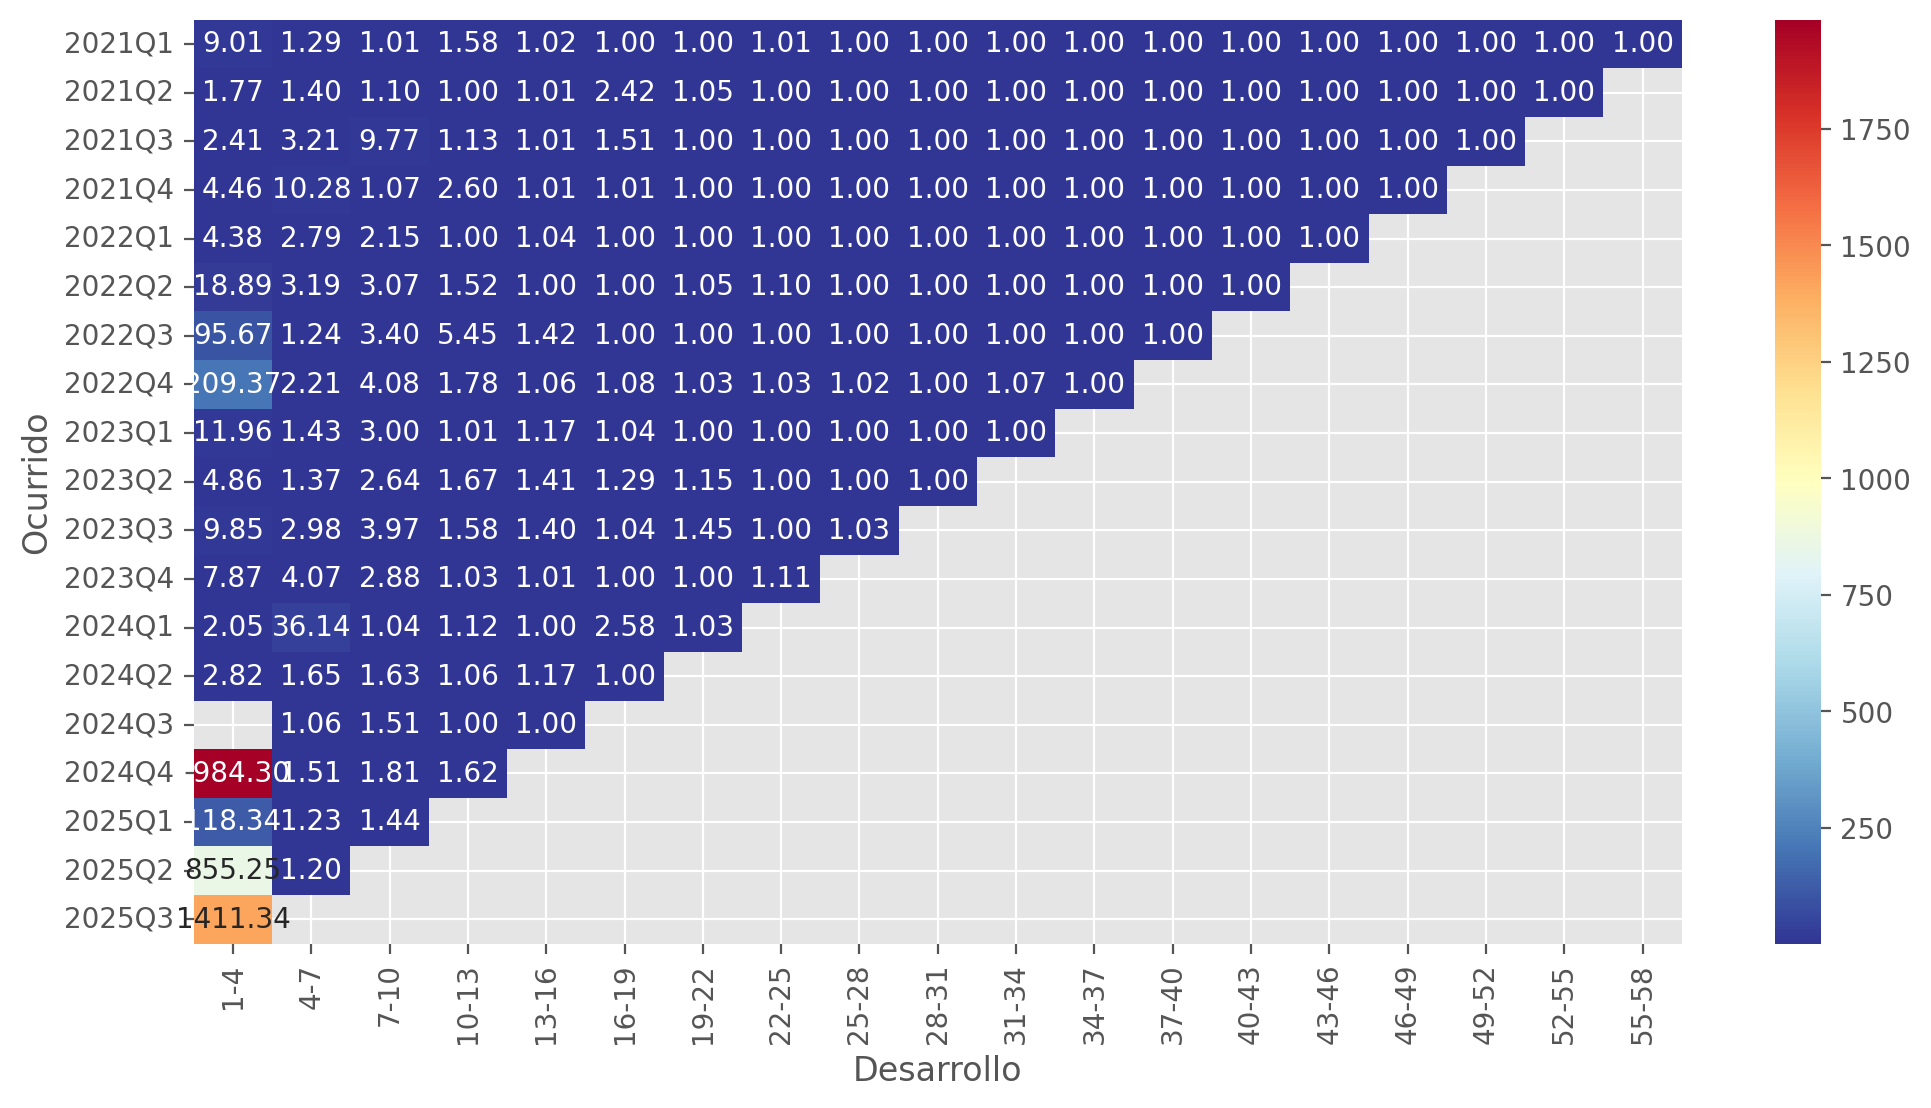

In [67]:
#creamos factores de desarrollo y mapa de calor
ax = pag_acum.link_ratio.heatmap()

df_lr = pag_acum.link_ratio
df_lr = pag_acum.link_ratio.to_frame()  # o .values según la librería

plt.figure(figsize=(12,6))

sns.heatmap(
    df_lr,
    cmap="RdYlBu_r",
    annot=True,   # cambia a True si quieres números
    fmt=".2f",
    cbar=True
)


plt.xlabel("Desarrollo")
plt.ylabel("Ocurrido")

plt.savefig("link_ratios_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
pag_acum.link_ratio.heatmap()

,1-4,4-7,7-10,10-13,13-16,16-19,19-22,22-25,25-28,28-31,31-34,34-37,37-40,40-43,43-46,46-49,49-52,52-55,55-58
2021Q1,9.01,1.29,1.01,1.58,1.02,1.00,1.00,1.01,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
2021Q2,1.77,1.40,1.10,1.00,1.01,2.42,1.05,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,
2021Q3,2.41,3.21,9.77,1.13,1.01,1.51,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,,
2021Q4,4.46,10.28,1.07,2.60,1.01,1.01,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,,,
2022Q1,4.38,2.79,2.15,1.00,1.04,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,,,,
2022Q2,18.89,3.19,3.07,1.52,1.00,1.00,1.05,1.10,1.00,1.00,1.00,1.00,1.00,1.00,,,,,
2022Q3,95.67,1.24,3.40,5.45,1.42,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,,,,,,
2022Q4,209.37,2.21,4.08,1.78,1.06,1.08,1.03,1.03,1.02,1.00,1.07,1.00,,,,,,,
2023Q1,11.96,1.43,3.00,1.01,1.17,1.04,1.00,1.00,1.00,1.00,1.00,,,,,,,,
2023Q2,4.86,1.37,2.64,1.67,1.41,1.29,1.15,1.00,1.00,1.00,,,,,,,,,


In [69]:
print(ocu_acum.valuation_correlation().z_critical)
print(pag_acum.valuation_correlation().z_critical)


        2020Q4  2021Q1  2021Q2  2021Q3  2021Q4  2022Q1  2022Q2  2022Q3  2022Q4  2023Q1  2023Q2  2023Q3  2023Q4  2024Q1  2024Q2  2024Q3  2024Q4  2025Q1  2025Q2
2021Q1   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False    True   False   False   False
        2020Q4  2021Q1  2021Q2  2021Q3  2021Q4  2022Q1  2022Q2  2022Q3  2022Q4  2023Q1  2023Q2  2023Q3  2023Q4  2024Q1  2024Q2  2024Q3  2024Q4  2025Q1  2025Q2
2021Q1   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False   False


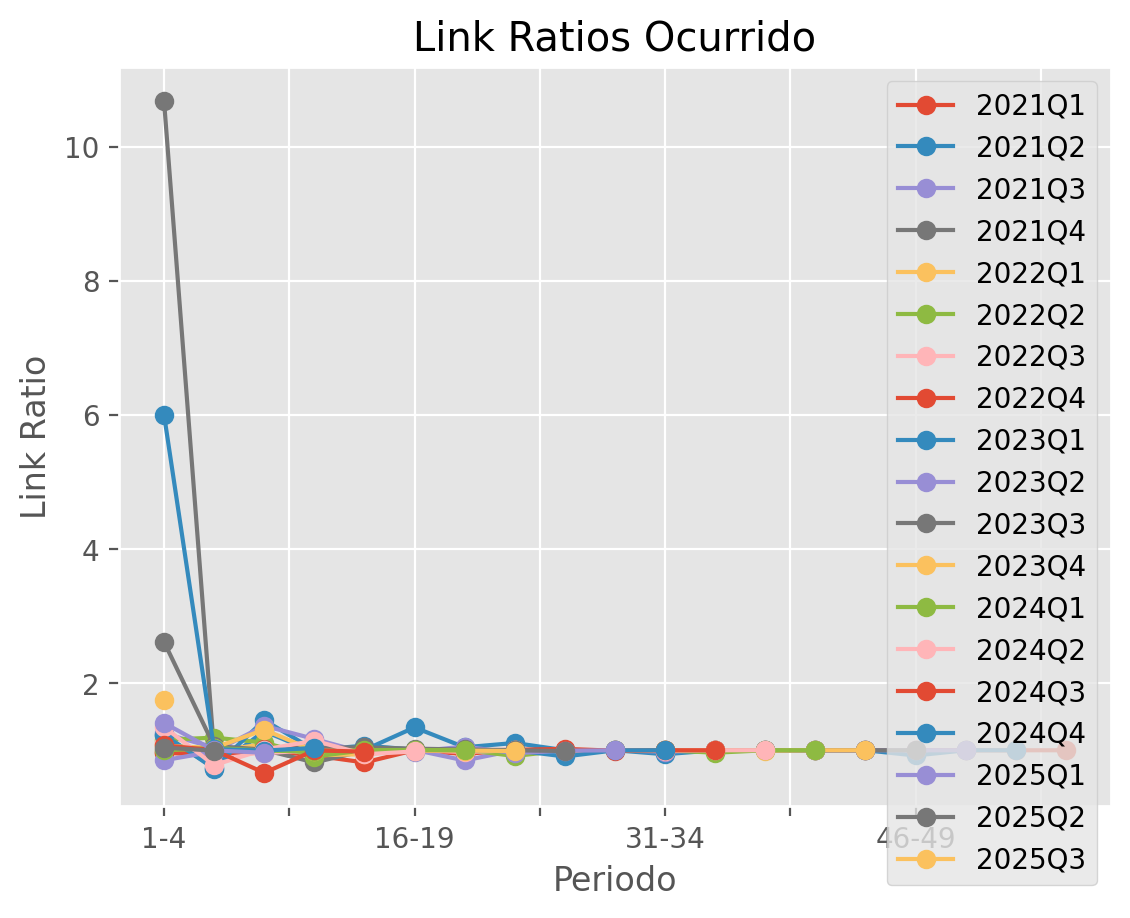

In [70]:
ax = ocu_acum.link_ratio.T.plot(
    marker='o', 
    title='Link Ratios Ocurrido',
    ylabel='Link Ratio', xlabel='Periodo');

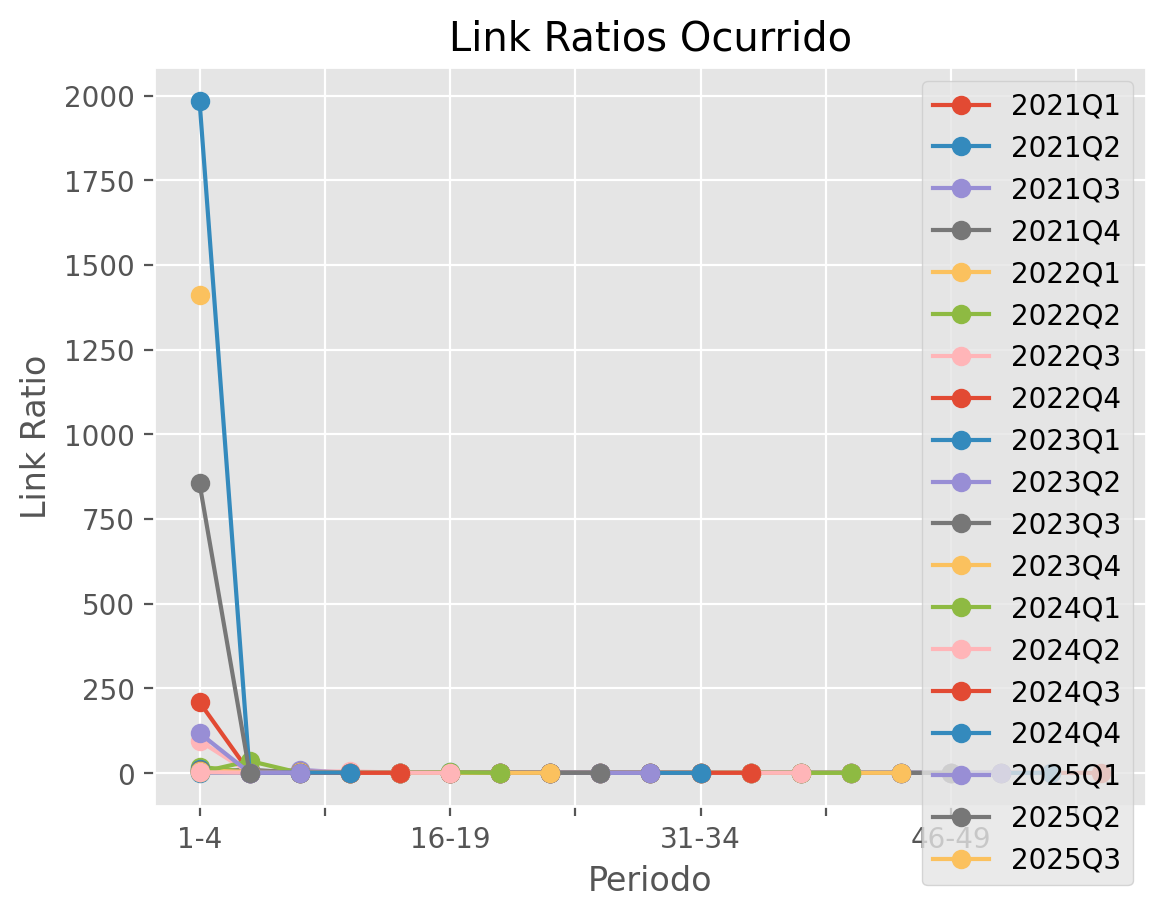

In [71]:
ax = pag_acum.link_ratio.T.plot(
    marker='o', 
    title='Link Ratios Ocurrido',
    ylabel='Link Ratio', xlabel='Periodo');

In [72]:
dev_ocu = cl.Development().fit(ocu_acum)
dev_pag = cl.Development().fit(pag_acum)

print(dev_ocu.cdf_)
print(dev_pag.cdf_)

          1-Ult     4-Ult     7-Ult    10-Ult   13-Ult  16-Ult    19-Ult    22-Ult    25-Ult   28-Ult    31-Ult    34-Ult    37-Ult    40-Ult  43-Ult    46-Ult    49-Ult  52-Ult  55-Ult
(All)  1.532941  0.940742  0.955406  0.933758  0.95852  0.9791  0.973903  0.984212  0.985668  0.99121  0.992698  0.995316  0.996619  0.997314  0.9973  0.997299  1.000001     1.0     1.0
           1-Ult     4-Ult    7-Ult    10-Ult    13-Ult    16-Ult    19-Ult    22-Ult    25-Ult    28-Ult    31-Ult    34-Ult    37-Ult    40-Ult    43-Ult    46-Ult    49-Ult  52-Ult  55-Ult
(All)  94.501168  8.005582  3.65064  2.031156  1.319305  1.214633  1.099922  1.042092  1.023812  1.014195  1.014146  1.000188  1.000179  1.000049  1.000035  1.000034  1.000001     1.0     1.0


In [73]:
exp_ocu = cl.TailCurve(curve="exponential").fit(ocu_acum)
exp_pag = cl.TailCurve(curve="exponential").fit(pag_acum)

print(exp_ocu.tail_)
print(exp_pag.tail_)

       58-Ult
(All)     1.0
         58-Ult
(All)  1.000001


In [74]:
inv_ocu = cl.TailCurve(curve="inverse_power").fit(ocu_acum)
inv_pag = cl.TailCurve(curve="inverse_power").fit(pag_acum)

print(inv_ocu.tail_)
print(inv_pag.tail_)

         58-Ult
(All)  1.000079
         58-Ult
(All)  1.000298


In [75]:
#fijamos los factores de cola usando inverse_power
tf_ocu = inv_ocu.tail_.iloc[0, 0]
tf_pag = inv_pag.tail_.iloc[0, 0]

Inicia el modelo

In [76]:
# funciones actuariales
def triangle_to_link_ratios(triangle: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula link ratios por fila:
    LR_{i,j} = C_{i,j+1} / C_{i,j}
    Se espera triángulo acumulado.
    """
    lr = triangle.copy().astype(float)
    for j in range(triangle.shape[1] - 1):
        col_j = triangle.columns[j]
        col_j1 = triangle.columns[j + 1]
        lr[col_j] = np.where(
            triangle[col_j].replace(0, np.nan).notna(),
            triangle[col_j1] / triangle[col_j].replace(0, np.nan),
            np.nan
        )
    lr = lr.iloc[:, :-1]
    return lr


def volume_weighted_ldf(triangle: pd.DataFrame) -> pd.Series:
    """
    Calcula factores de desarrollo promedio volumen-ponderados:
    f_j = sum(C_{i,j+1}) / sum(C_{i,j})
    """
    ldfs = {}
    cols = list(triangle.columns)
    for j in range(len(cols) - 1):
        c0 = cols[j]
        c1 = cols[j + 1]

        mask = triangle[[c0, c1]].notna().all(axis=1)
        denom = triangle.loc[mask, c0].sum()
        numer = triangle.loc[mask, c1].sum()

        if denom == 0:
            ldfs[c0] = np.nan
        else:
            ldfs[c0] = numer / denom

    return pd.Series(ldfs, name="ldf")


def cumulative_development_factors(ldf: pd.Series, tail_factor: float = 1.0) -> pd.Series:
    """
    Convierte LDF a CDF:
    CDF_j = f_j * f_{j+1} * ... * tail
    """
    vals = ldf.values.astype(float)
    cdf = np.ones(len(vals))
    running = tail_factor

    for i in range(len(vals) - 1, -1, -1):
        running *= vals[i]
        cdf[i] = running

    return pd.Series(cdf, index=ldf.index, name="cdf")


def latest_diagonal(triangl: pd.DataFrame) -> pd.Series:
    """
    Extrae el último valor no nulo por fila.
    """
    return triangl.apply(lambda row: row.dropna().iloc[-1] if row.dropna().shape[0] > 0 else np.nan, axis=1)


def latest_age_index(triangl: pd.DataFrame) -> pd.Series:
    """
    Devuelve el índice de la última columna no nula por fila.
    """
    return triangl.apply(lambda row: row.dropna().index[-1] if row.dropna().shape[0] > 0 else np.nan, axis=1)


def chain_ladder_ultimate(triangl: pd.DataFrame, tail_factor: float = 1.0) -> pd.DataFrame:
    """
    Estima ultimate y reserva base con Chain Ladder simplificado.
    """
    ldf = volume_weighted_ldf(triangl)
    cdf = cumulative_development_factors(ldf, tail_factor=tail_factor)

    latest_vals = latest_diagonal(triangl)
    latest_age = latest_age_index(triangl)

    # mapear edad -> CDF
    cdf_map = cdf.to_dict()

    ultimates = []
    reserves = []

    for idx in triangl.index:
        age = latest_age.loc[idx]
        latest_val = latest_vals.loc[idx]

        if pd.isna(age) or pd.isna(latest_val):
            ult = np.nan
            res = np.nan
        elif age in cdf_map:
            ult = latest_val * cdf_map[age]
            res = ult - latest_val
        else:
            # si ya está en última edad observada
            ult = latest_val * tail_factor
            res = ult - latest_val

        ultimates.append(ult)
        reserves.append(res)

    out = pd.DataFrame({
        "latest": latest_vals,
        "latest_age": latest_age,
        "ultimate_cl": ultimates,
        "reserve_cl": reserves
    }, index=triangl.index)

    return out

In [77]:
# 2. CONSTRUCCIÓN DE FEATURES

def build_feature_table(
    tri_ocu: pd.DataFrame,
    tri_pag: pd.DataFrame,
    prima_dev: pd.Series,
    indice: pd.Series,
    tail_factor_ocu: float = tf_ocu,
    tail_factor_pag: float = tf_pag
) -> pd.DataFrame:
    """
    Construye tabla de variables explicativas por cohorte de ocurrencia.
    """

    # Reservas base
    ocu_cl = chain_ladder_ultimate(tri_ocu, tail_factor=tail_factor_ocu)
    pag_cl = chain_ladder_ultimate(tri_pag, tail_factor=tail_factor_pag)

    # Link ratios promedio
    ocu_lr = triangle_to_link_ratios(tri_ocu)
    pag_lr = triangle_to_link_ratios(tri_pag)

    ocu_lr_mean = ocu_lr.mean(axis=1, skipna=True).rename("ocu_lr_mean")
    ocu_lr_std = ocu_lr.std(axis=1, skipna=True).rename("ocu_lr_std")

    pag_lr_mean = pag_lr.mean(axis=1, skipna=True).rename("pag_lr_mean")
    pag_lr_std = pag_lr.std(axis=1, skipna=True).rename("pag_lr_std")

    latest_ocu = latest_diagonal(tri_ocu).rename("latest_ocu")
    latest_pag = latest_diagonal(tri_pag).rename("latest_pag")

    latest_age_ocu = latest_age_index(tri_ocu).rename("latest_age_ocu")
    latest_age_pag = latest_age_index(tri_pag).rename("latest_age_pag")

    # Relación ocurrido/pagado
    ratio_ocu_pag = (latest_ocu / latest_pag.replace(0, np.nan)).rename("ratio_ocu_pag")

    df = pd.concat([
        ocu_cl.add_prefix("ocu_"),
        pag_cl.add_prefix("pag_"),
        ocu_lr_mean,
        ocu_lr_std,
        pag_lr_mean,
        pag_lr_std,
        latest_ocu,
        latest_pag,
        latest_age_ocu,
        latest_age_pag,
        ratio_ocu_pag,
        prima_dev.rename("prima_dev"),
        indice.rename("indice")
    ], axis=1)

    # Variables adicionales útiles
    df["reserve_ratio_ocu"] = df["ocu_reserve_cl"] / df["prima_dev"].replace(0, np.nan)
    df["reserve_ratio_pag"] = df["pag_reserve_cl"] / df["prima_dev"].replace(0, np.nan)
    df["gap_ocu_pag"] = df["latest_ocu"] - df["latest_pag"]
    df["gap_ocu_pag_ratio"] = df["gap_ocu_pag"] / df["latest_ocu"].replace(0, np.nan)

    # Orden temporal
    df = df.sort_index()

    return df


In [78]:
# 3. VARIABLE OBJETIVO PARA ENTRENAMIENTO

def build_training_target(
    tri_ocu: pd.DataFrame,
    horizon_shift: int = 1
) -> pd.Series:
  
    current_latest = latest_diagonal(tri_ocu)
    future_latest = current_latest.shift(-horizon_shift)
    target = (future_latest - current_latest).rename("target_proxy")
    return target

In [79]:
# 4. ENTORNO DE REINFORCEMENT LEARNING

class ReservingEnv(gym.Env):
    """
    Entorno simple:
    - Estado: features de la cohorte t
    - Acción: ajuste porcentual sobre reserva base
    - Recompensa: error contra target observado + penalización por sub-reservar
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        X: pd.DataFrame,
        base_reserve: pd.Series,
        target: pd.Series,
        action_grid: Optional[List[float]] = None,
        underreserve_penalty: float = 2.0,
        volatility_penalty: float = 0.1
    ):
        super().__init__()

        self.X = X.copy()
        self.base_reserve = base_reserve.copy()
        self.target = target.copy()

        valid_idx = self.X.index.intersection(self.base_reserve.dropna().index).intersection(self.target.dropna().index)
        self.X = self.X.loc[valid_idx].dropna()
        self.base_reserve = self.base_reserve.loc[self.X.index]
        self.target = self.target.loc[self.X.index]

        self.n_steps = len(self.X)
        self.current_step = 0
        self.prev_action = 0.0

        if action_grid is None:
            action_grid = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]
        self.action_grid = action_grid

        self.underreserve_penalty = underreserve_penalty
        self.volatility_penalty = volatility_penalty

        self.observation_dim = self.X.shape[1]

        self.action_space = spaces.Discrete(len(self.action_grid))
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(self.observation_dim,),
            dtype=np.float32
        )

    def _get_obs(self):
        return self.X.iloc[self.current_step].values.astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        self.prev_action = 0.0
        return self._get_obs(), {}

    def step(self, action):
        action_adj = self.action_grid[action]

        base = self.base_reserve.iloc[self.current_step]
        y_true = self.target.iloc[self.current_step]

        reserve_pred = base * (1.0 + action_adj)

        error = reserve_pred - y_true
        abs_error = abs(error)

        # castigo extra por subreservar
        underreserve = max(y_true - reserve_pred, 0.0)

        # castigo por movimientos bruscos
        action_change = abs(action_adj - self.prev_action)

        reward = (
            - abs_error
            - self.underreserve_penalty * underreserve
            - self.volatility_penalty * action_change * abs(base)
        )

        self.prev_action = action_adj
        self.current_step += 1

        terminated = self.current_step >= self.n_steps
        truncated = False

        if not terminated:
            obs = self._get_obs()
        else:
            obs = np.zeros(self.observation_dim, dtype=np.float32)

        info = {
            "base_reserve": base,
            "target": y_true,
            "reserve_pred": reserve_pred,
            "action_adjustment": action_adj,
            "error": error,
            "reward": reward
        }

        return obs, reward, terminated, truncated, info

    def render(self):
        pass

In [80]:
# 5. PREPARACIÓN COMPLETA

def prepare_model_data(
    tri_ocu: pd.DataFrame,
    tri_pag: pd.DataFrame,
    prima_dev: pd.Series,
    indice: pd.Series
) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """
    Devuelve:
    X           -> features
    base_reserve -> reserva base a ajustar
    target      -> objetivo observado
    """

    # Alinear índices
    common_idx = tri_ocu.index.intersection(tri_pag.index).intersection(prima_dev.index).intersection(indice.index)

    tri_ocu = tri_ocu.loc[common_idx]
    tri_pag = tri_pag.loc[common_idx]
    prima_dev = prima_dev.loc[common_idx]
    indice = indice.loc[common_idx]

    # Features
    df_feat = build_feature_table(
        tri_ocu=tri_ocu,
        tri_pag=tri_pag,
        prima_dev=prima_dev,
        indice=indice,
        tail_factor_ocu=1,
        tail_factor_pag=1
    )

    # Reserva base
    base_reserve = df_feat["ocu_reserve_cl"]

    # Target
    target = build_training_target(tri_ocu)

    # Alinear
    valid_idx = df_feat.index.intersection(base_reserve.dropna().index).intersection(target.dropna().index)
    df_feat = df_feat.loc[valid_idx]
    base_reserve = base_reserve.loc[valid_idx]
    target = target.loc[valid_idx]

    money_cols = [
    "ocu_latest", "ocu_ultimate_cl", "ocu_reserve_cl",
    "pag_latest", "pag_ultimate_cl", "pag_reserve_cl",
    "latest_ocu", "latest_pag", "gap_ocu_pag", "prima_dev"
]

    for col in money_cols:
        if col in df_feat.columns:
            df_feat[col] = df_feat[col] / 1_000_000

    base_reserve = base_reserve / 1_000_000
    target = target / 1_000_000

    return df_feat, base_reserve, target

In [81]:
# pasamos a dataframe los triangle
df_ocu = ocu_acum.to_frame()
df_pag = pag_acum.to_frame()

# pasamos a serie prima dev y el indice

pr_dev = pr_dev.set_index(pr_dev.columns[0])[pr_dev.columns[1]]
pr_dev.index = pd.to_datetime(pr_dev.index)


ind_risk = ind_risk.set_index(ind_risk.columns[0])[ind_risk.columns[1]]
ind_risk.index = pd.to_datetime(ind_risk.index)


In [82]:
# 6. EJEMPLO DE USO

X, base_reserve, target = prepare_model_data(
     tri_ocu=df_ocu,
     tri_pag=df_pag,
     prima_dev=pr_dev,
     indice=ind_risk
 )


env = ReservingEnv(
    X=X,
    base_reserve=base_reserve,
    target=target,
    action_grid=[-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20],
    underreserve_penalty=2.0,
    volatility_penalty=0.000001
)

obs, info = env.reset()
done = False
total_reward = 0

while not done:
    action = env.action_space.sample()
    obs, reward, done, truncated, step_info = env.step(action)
    total_reward += reward

print("Reward total episodio:", total_reward)

Reward total episodio: -3413.8340811711523


In [83]:
def make_env():
    return Monitor(
        ReservingEnv(
            X=X,
            base_reserve=base_reserve,
            target=target,
            action_grid=[-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20],
            underreserve_penalty=2.0,
            volatility_penalty=0.000001
        )
    )

vec_env = DummyVecEnv([make_env])

In [84]:
%load_ext tensorboard

In [85]:
#entrenar el modelo DQN
model = DQN(
    policy="MlpPolicy",
    env=vec_env,
    learning_rate=1e-3,
    buffer_size=5000,
    learning_starts=200,
    batch_size=32,
    tau=1.0,
    gamma=0.95,
    train_freq=1,
    gradient_steps=1,
    target_update_interval=250,
    exploration_fraction=0.30,
    exploration_initial_eps=1.0,
    exploration_final_eps=0.05,
    verbose=1,
    tensorboard_log="./dqn_reserving_tensorboard/"
)

Using cpu device


In [86]:
model.learn(total_timesteps=10000, tb_log_name="DQN_reserving")

Logging to ./dqn_reserving_tensorboard/DQN_reserving_2
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 18        |
|    ep_rew_mean      | -3.42e+03 |
|    exploration_rate | 0.977     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 1647      |
|    time_elapsed     | 0         |
|    total_timesteps  | 72        |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 18        |
|    ep_rew_mean      | -3.42e+03 |
|    exploration_rate | 0.954     |
| time/               |           |
|    episodes         | 8         |
|    fps              | 2087      |
|    time_elapsed     | 0         |
|    total_timesteps  | 144       |
-----------------------------------
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 18        |
|    ep_rew_mean      | -3.42e+03 |
|    expl

In [87]:
event_files = []
for root, dirs, files in os.walk("./dqn_reserving_tensorboard/"):
    for f in files:
        if "tfevents" in f:
            event_files.append(os.path.join(root, f))

print(event_files)

['./dqn_reserving_tensorboard/DQN_reserving_1\\events.out.tfevents.1776488143.rulo_surface.42124.1', './dqn_reserving_tensorboard/DQN_reserving_2\\events.out.tfevents.1776528027.rulo_surface.44676.0']


In [88]:
print(sys.executable)

c:\Users\darkr\miniconda3\python.exe


In [89]:
subprocess.Popen([
    sys.executable,
    "-m",
    "tensorboard.main",
    "--logdir=./dqn_reserving_tensorboard/"
])

<Popen: returncode: None args: ['c:\\Users\\darkr\\miniconda3\\python.exe', ...>

In [90]:
eval_env = ReservingEnv(
    X=X,
    base_reserve=base_reserve,
    target=target,
    action_grid=[-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20],
    underreserve_penalty=2.0,
    volatility_penalty=0.000001
)

In [91]:
# evaluacion del modelo ya entrenado
obs, info = eval_env.reset()
done = False
results = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, step_info = eval_env.step(int(action))
    results.append(step_info)

results_df = pd.DataFrame(results)
results_df.head()

,base_reserve,target,reserve_pred,action_adjustment,error,reward
0,0.000000,-81.448754,0.000000,0.10,81.448754,-81.448754
1,0.000000,26.111335,0.000000,0.10,-26.111335,-78.334004
2,0.000000,164.596662,0.000000,0.10,-164.596662,-493.789987
3,0.000151,-132.878798,0.000158,0.05,132.878956,-132.878956
4,-0.185812,-47.359605,-0.204393,0.10,47.155212,-47.155212


In [92]:
print(results_df["action_adjustment"].value_counts())
print(results_df.describe())

action_adjustment
 0.10    14
 0.05     3
-0.05     1
Name: count, dtype: int64
       base_reserve      target  reserve_pred  action_adjustment       error  \
count     18.000000   18.000000     18.000000          18.000000   18.000000   
mean      -1.656335   -1.287465     -1.768680           0.083333   -0.481216   
std        3.621336  136.346389      3.921105           0.038348  134.092057   
min      -14.899650 -322.336276    -16.389615          -0.050000 -328.663768   
25%       -1.221825  -67.894554     -1.344007           0.100000  -70.013998   
50%       -0.322021   -8.172422     -0.342767           0.100000    7.386057   
75%       -0.078868   69.886403     -0.084983           0.100000   63.098671   
max        0.000151  327.945295      0.000158           0.100000  305.946661   

           reward  
count   18.000000  
mean  -189.701333  
std    241.273383  
min   -985.991305  
25%   -291.621637  
50%    -87.838518  
75%    -50.630489  
max     -6.854057  


In [100]:
# MÉTRICAS DEL MODELO RL
# ============================================================

# Errores RL
results_df["abs_error"] = results_df["error"].abs()
results_df["sq_error"] = results_df["error"] ** 2
results_df["underreserve"] = (results_df["target"] - results_df["reserve_pred"]).clip(lower=0)
results_df["overreserve"] = (results_df["reserve_pred"] - results_df["target"]).clip(lower=0)

# Benchmark base (sin ajuste RL)
results_df["benchmark_pred"] = results_df["base_reserve"]
results_df["benchmark_error"] = results_df["benchmark_pred"] - results_df["target"]
results_df["benchmark_abs_error"] = results_df["benchmark_error"].abs()
results_df["benchmark_sq_error"] = results_df["benchmark_error"] ** 2
results_df["benchmark_underreserve"] = (results_df["target"] - results_df["benchmark_pred"]).clip(lower=0)
results_df["benchmark_overreserve"] = (results_df["benchmark_pred"] - results_df["target"]).clip(lower=0)

# Métricas de estabilidad
results_df["action_change"] = results_df["action_adjustment"].diff().abs()
results_df["reserve_change"] = results_df["reserve_pred"].diff().abs()

# Tabla comparativa principal
comparison = pd.DataFrame({
    "RL": [
        results_df["abs_error"].mean(),
        np.sqrt(results_df["sq_error"].mean()),
        results_df["error"].mean(),
        results_df["underreserve"].mean(),
        (results_df["underreserve"] > 0).mean(),
        results_df["overreserve"].mean(),
        (results_df["overreserve"] > 0).mean(),
        results_df["action_change"].mean(),
        results_df["reserve_change"].std(),
        results_df["reward"].mean(),
        results_df["reward"].sum()
    ],
    "Base": [
        results_df["benchmark_abs_error"].mean(),
        np.sqrt(results_df["benchmark_sq_error"].mean()),
        results_df["benchmark_error"].mean(),
        results_df["benchmark_underreserve"].mean(),
        (results_df["benchmark_underreserve"] > 0).mean(),
        results_df["benchmark_overreserve"].mean(),
        (results_df["benchmark_overreserve"] > 0).mean(),
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ]
}, index=[
    "MAE",
    "RMSE",
    "Bias",
    "Underreserve promedio",
    "Frecuencia subreservación",
    "Overreserve promedio",
    "Frecuencia sobrereservación",
    "Cambio promedio de acción",
    "Volatilidad reserva ajustada",
    "Reward promedio",
    "Reward total"
])

print("======== MÉTRICAS COMPARATIVAS RL vs BASE ========")
print(comparison)
print("\n")

print("======== DISTRIBUCIÓN DE ACCIONES DEL AGENTE ========")
print(results_df["action_adjustment"].value_counts().sort_index())
print("\n")

print("======== RESUMEN DESCRIPTIVO DE RESULTADOS ========")
print(results_df[[
    "base_reserve", "target", "reserve_pred",
    "action_adjustment", "error", "reward"
]].describe())
print("\n")

======== MÉTRICAS COMPARATIVAS RL vs BASE ========
                                       RL        Base
MAE                             94.610058   94.663594
RMSE                           130.314944  130.486933
Bias                            -0.481216   -0.368870
Underreserve promedio           47.545637   47.516232
Frecuencia subreservación        0.500000    0.500000
Overreserve promedio            47.064421   47.147362
Frecuencia sobrereservación      0.500000    0.500000
Cambio promedio de acción        0.020588         NaN
Volatilidad reserva ajustada     4.810604         NaN
Reward promedio               -189.701333         NaN
Reward total                 -3414.623989         NaN


======== DISTRIBUCIÓN DE ACCIONES DEL AGENTE ========
action_adjustment
-0.05     1
 0.05     3
 0.10    14
Name: count, dtype: int64


======== RESUMEN DESCRIPTIVO DE RESULTADOS ========
       base_reserve      target  reserve_pred  action_adjustment       error  \
count     18.000000   18.000000

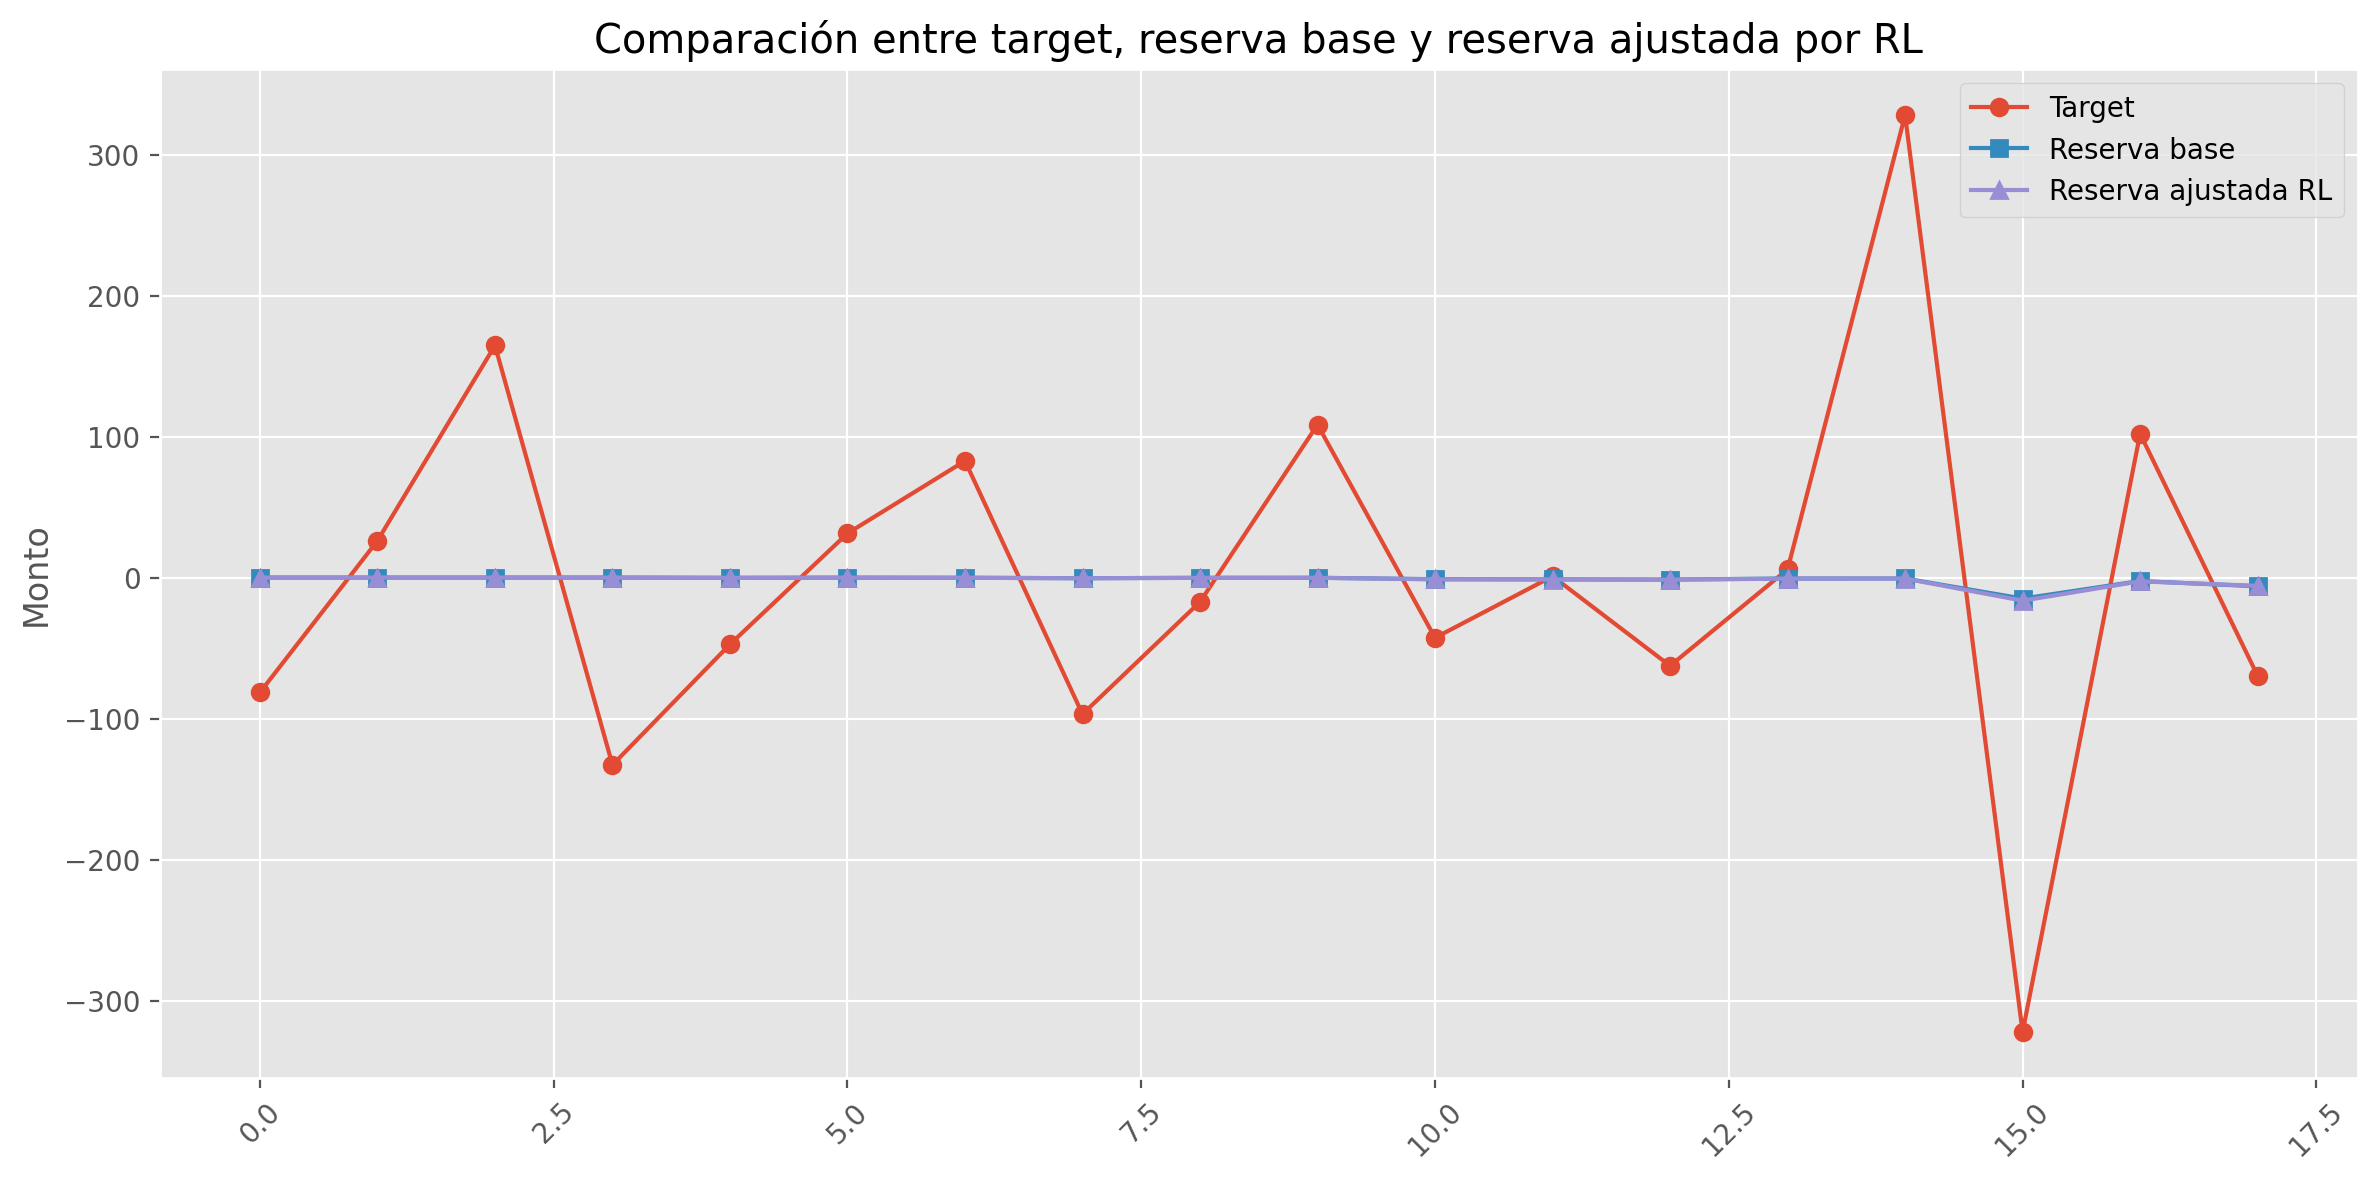

In [101]:
#GRÁFICA: TARGET vs BASE vs RL

plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df["target"], marker="o", label="Target")
plt.plot(results_df.index, results_df["base_reserve"], marker="s", label="Reserva base")
plt.plot(results_df.index, results_df["reserve_pred"], marker="^", label="Reserva ajustada RL")
plt.xticks(rotation=45)
plt.ylabel("Monto")
plt.title("Comparación entre target, reserva base y reserva ajustada por RL")
plt.legend()
plt.tight_layout()
plt.show()

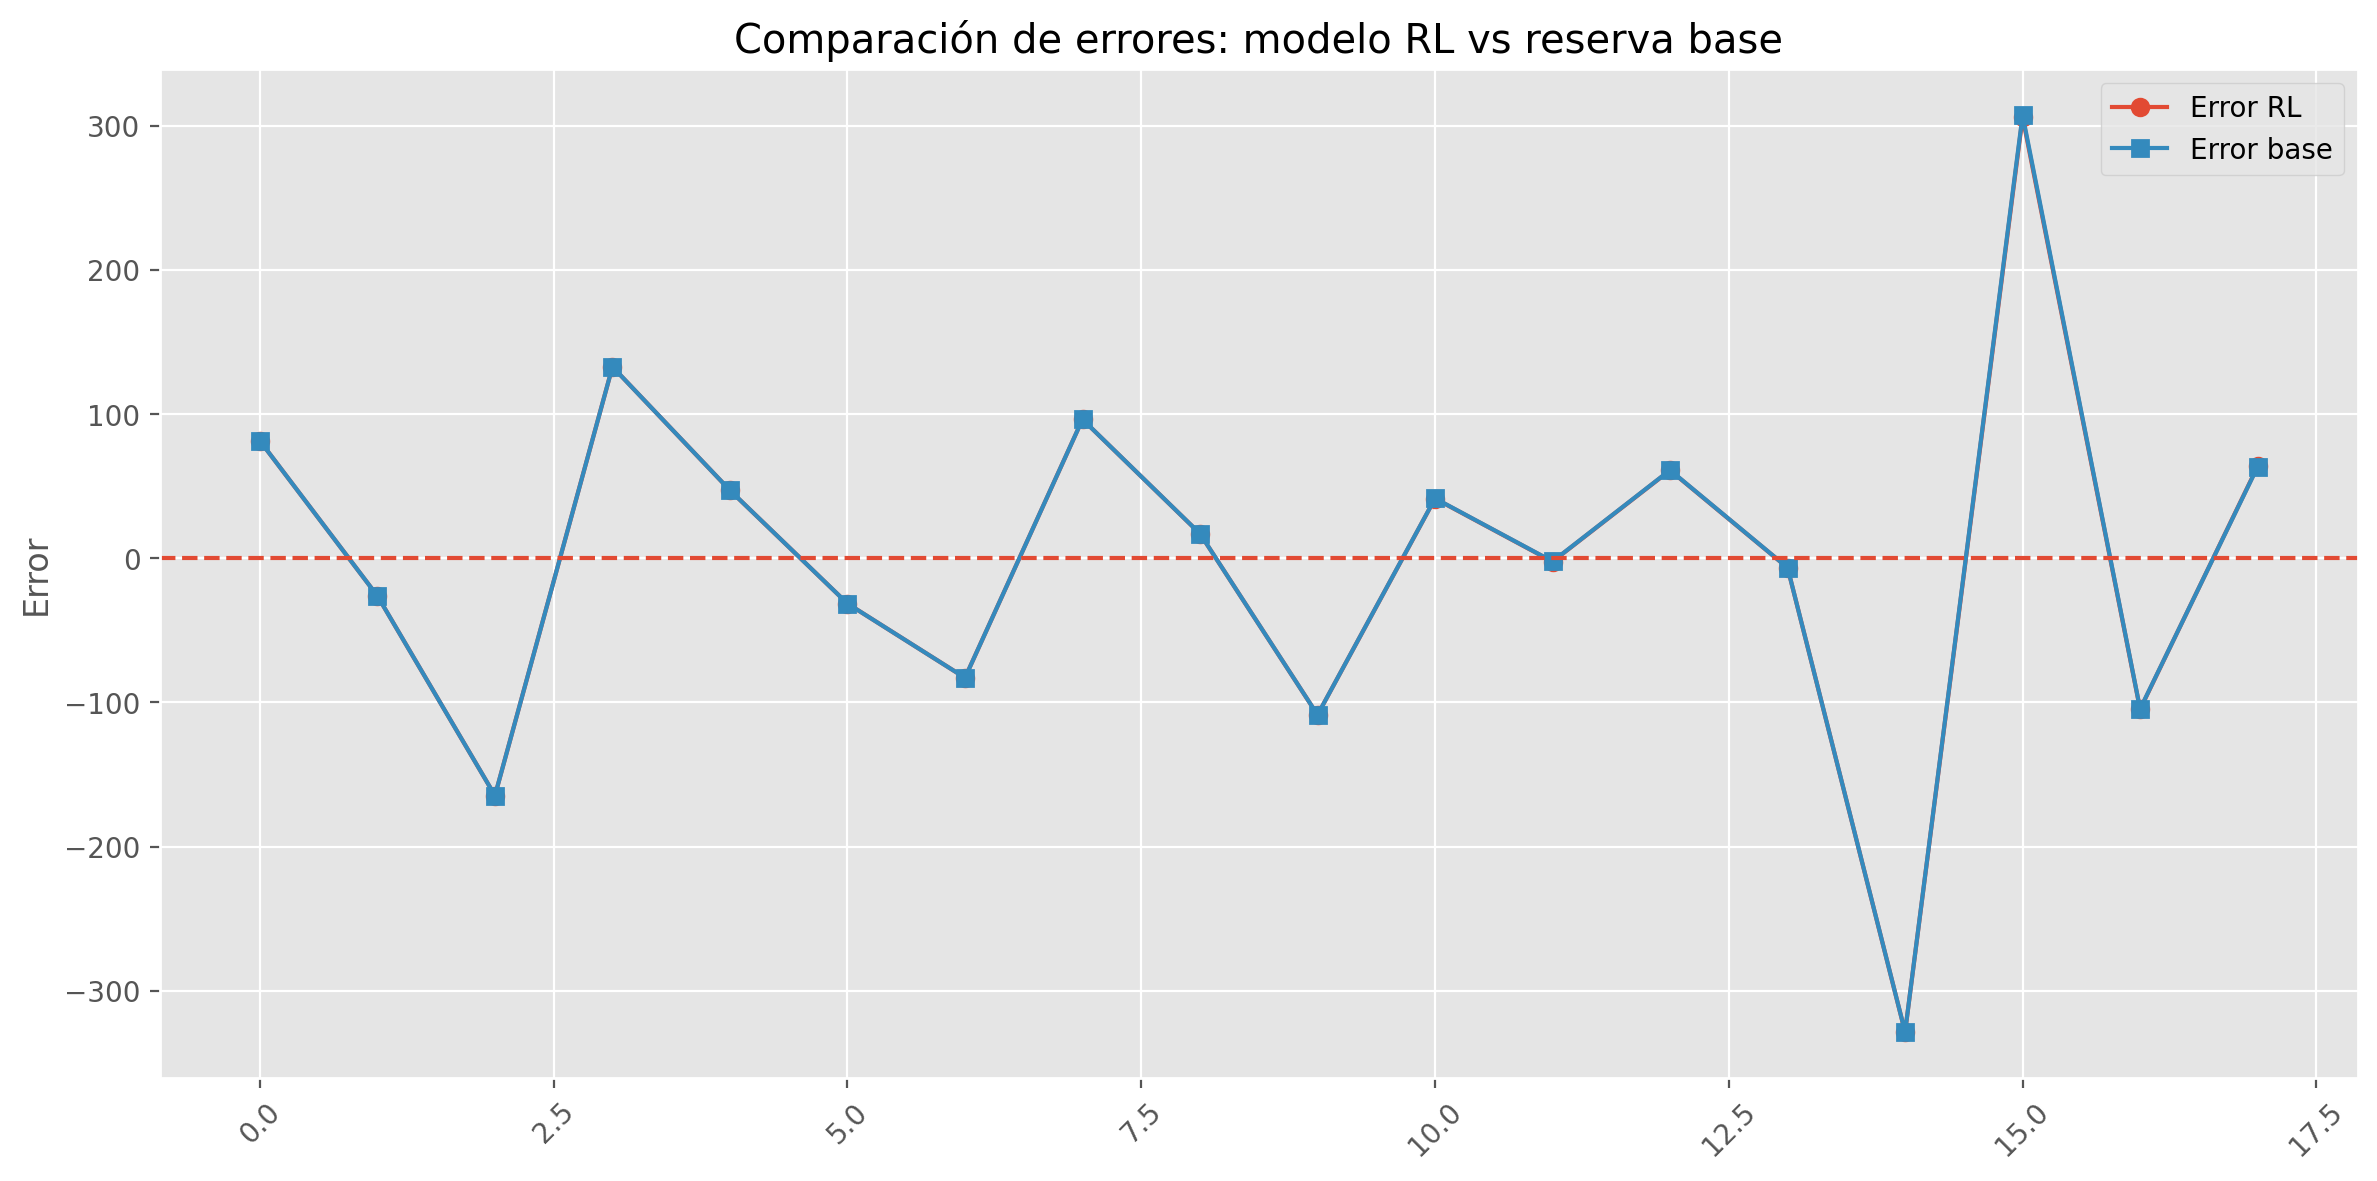

In [102]:
# GRÁFICA: ERROR RL vs ERROR BASE

plt.figure(figsize=(12, 6))
plt.plot(results_df.index, results_df["error"], marker="o", label="Error RL")
plt.plot(results_df.index, results_df["benchmark_error"], marker="s", label="Error base")
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.ylabel("Error")
plt.title("Comparación de errores: modelo RL vs reserva base")
plt.legend()
plt.tight_layout()
plt.show()